<a href="https://colab.research.google.com/github/amitsingh6261/Machine_learning/blob/main/DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import os
import zipfile
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

np.random.seed(42)
random.seed(42)
keras.utils.set_random_seed(42)
import warnings
warnings.filterwarnings('ignore')

print("keras version:",keras.__version__)
print("Numpy version:",np.__version__)
print("Backend:",keras.backend.backend())

keras version: 3.13.2
Numpy version: 2.1.3
Backend: tensorflow


In [25]:
(x_train,y_train),(x_test,y_test) = keras.datasets.fashion_mnist.load_data()
print("x_train shape:",x_train.shape)
print("y_train shape:",y_train.shape)
print("x_test shape:",x_test.shape)
print("y_test shape:",y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


First image shape: (28, 28)
First image label: 9


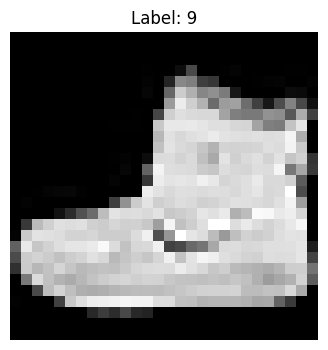

In [26]:
print("First image shape:", x_train[0].shape)

print("First image label:", y_train[0])

plt.figure(figsize=(4, 4))

plt.imshow(x_train[0], cmap="gray")

plt.title(f"Label: {y_train[0]}")

plt.axis("off")

plt.show()

In [27]:
class_name = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"]
for i, name in enumerate(class_name):
  print(i,"->" ,name)

0 -> T-shirt/top
1 -> Trouser
2 -> Pullover
3 -> Dress
4 -> Coat
5 -> Sandal
6 -> Shirt
7 -> Sneaker
8 -> Bag
9 -> Ankle boot


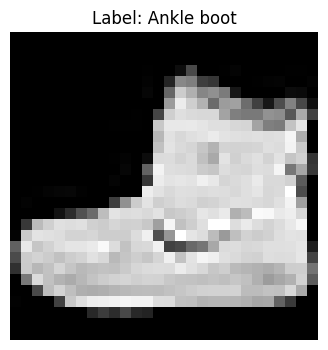

In [28]:
label = y_train[0]
plt.figure(figsize=(4,4))
plt.imshow(x_train[0],cmap="gray")
plt.title(f"Label: {class_name[label]}")
plt.axis("off")
plt.show()

In [29]:
print("training image data type:",x_train.dtype)
print("Minimum pixel value:",x_train.min())
print("Maximum pixel value:",x_train.max())

print("NaN values in training images:",np.isnan(x_train).sum())
print("NaN values in test image:",np.isnan(x_test).sum())

print("Infinite values in training images:",np.isinf(x_train).sum())
print("Infinite values in test image:",np.isinf(x_test).sum())

training image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
NaN values in training images: 0
NaN values in test image: 0
Infinite values in training images: 0
Infinite values in test image: 0


In [30]:
duplicate_check = x_train[:2000].reshape(2000,-1)
unique_rows = np.unique(duplicate_check,axis=0)

print("Image checked:",len(duplicate_check))
print("Unique images:",len(unique_rows))
print("Duplicate images:",len(duplicate_check)-len(unique_rows))

Image checked: 2000
Unique images: 2000
Duplicate images: 0


In [31]:
duplicate_check = x_train[:2000].reshape(2000,-1)
unique_rows = np.unique(duplicate_check,axis=0)

print("Image checked:",len(duplicate_check))
print("Unique images:",len(unique_rows))
print("Duplicate images:",len(duplicate_check)-len(unique_rows))

Image checked: 2000
Unique images: 2000
Duplicate images: 0


In [32]:
TRAIN_POOL_SIZE = 10000

TEST_POOL_SIZE = 2000

x_POOL = x_train[:TRAIN_POOL_SIZE]
y_POOL = y_train[:TRAIN_POOL_SIZE]

x_test_small,_,y_test_small,_ = train_test_split(
    x_test,y_test,
    train_size=TEST_POOL_SIZE,
    random_state=42,
    stratify=y_test
    )
x_train_small, x_val_small, y_train_small, y_val_small = train_test_split(
    x_POOL, y_POOL,
    train_size=0.20,
    random_state=42,
    stratify=y_POOL
)

print("Training:",x_train_small.shape)
print("Validation:",x_val_small.shape)
print("Test:",x_test_small.shape)

Training: (2000, 28, 28)
Validation: (8000, 28, 28)
Test: (2000, 28, 28)


In [33]:
x_train_flat = x_train_small.reshape(len(x_train_small),-1)
x_val_flat = x_val_small.reshape(len(x_val_small),-1)
x_test_flat = x_test_small.reshape(len(x_test_small),-1)

print("original image shape", x_train_small[0].shape)
print("flattened sample shape", x_train_flat[0].shape)
print("Training matrix shape", x_train_flat.shape)

original image shape (28, 28)
flattened sample shape (784,)
Training matrix shape (2000, 784)


In [34]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    solver="lbfgs",
    max_iter=300,
    random_state=42
)
logistic_model.fit(x_train_flat, y_train_small)
print("Logistic regression training complete!")

Logistic regression training complete!
